## Ejercicio 1: Evaluación de solicitud de crédito bancario
**Problema:** un sistema evalúa automáticamente una solicitud de crédito, considerando:
* ingreso_mensual: un número (en soles)
* monto_solicitado: un número (en soles)
* tiene_historial_moroso: True o False
### Ficha PEAS
| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual, monto solicitado, historial moroso del solicitante |
| **Acciones (A)** | Aprobar, aprobar con condiciones, rechazar |
| **Entorno (E)** | Proceso de evaluación crediticia de un banco, con solicitantes de distinto perfil de riesgo |
| **Objetivo** | Otorgar crédito a quien puede pagarlo, minimizando el riesgo de impago |
| **Medida de desempeño (P)** | Tasa de impagos sobre créditos aprobados, y solicitudes válidas no rechazadas injustamente |

## Justificación de las Reglas de Decisión
1. Una cuota baja (≤0.3) se considera manejable, por lo que se aprueba incluso si existe un historial de morosidad leve.
2. Entre 0.3 y 0.5, el riesgo aumenta: sin antecedentes de morosidad se puede aprobar con algunas condiciones, pero si existen antecedentes, se rechaza.
3. Por encima de 0.5, la cuota es demasiado alta en relación con el ingreso, por lo que se rechaza.
| Condición | Acción |
|---|---|
| Relación ≤ 0.3 (sin importar historial) | Aprobar |
| Relación entre 0.3 y 0.5, sin historial moroso | Aprobar con condiciones |
| Relación entre 0.3 y 0.5, con historial moroso | Rechazar |
| Relación > 0.5 (sin importar historial) | Rechazar |zar |

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 0.3:
        return "aprobar", "relacion monto/ingreso baja (<=0.3), riesgo manejable"
    elif relacion <= 0.5:
        if tiene_historial_moroso:
            return "rechazar", "relacion monto/ingreso moderada (0.3-0.5) con historial moroso"
        else:
            return "aprobar con condiciones", "relacion monto/ingreso moderada (0.3-0.5) sin historial moroso"
    else:
        return "rechazar", "relacion monto/ingreso mayor a 0.5"

### Simulación y Pruebas

In [2]:
casos = [
    (3000, 500, False),   # relacion 0.167 -> aprobar
    (2000, 900, False),   # relacion 0.45 -> aprobar con condiciones
    (2000, 900, True),    # relacion 0.45 -> rechazar (mismo monto, con historial)
    (1500, 1200, False),  # relacion 0.8 -> rechazar
    (4000, 1200, False),  # relacion 0.3 exacto -> caso limite: aprobar
    (2500, 1250, False),  # relacion 0.5 exacto -> caso limite: aprobar con condiciones
]

for ingreso, monto, moroso in casos:
    resultado = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: {ingreso}, Monto: {monto}, Moroso: {moroso} -> {resultado}")

Ingreso: 3000, Monto: 500, Moroso: False -> ('aprobar', 'relacion monto/ingreso baja (<=0.3), riesgo manejable')
Ingreso: 2000, Monto: 900, Moroso: False -> ('aprobar con condiciones', 'relacion monto/ingreso moderada (0.3-0.5) sin historial moroso')
Ingreso: 2000, Monto: 900, Moroso: True -> ('rechazar', 'relacion monto/ingreso moderada (0.3-0.5) con historial moroso')
Ingreso: 1500, Monto: 1200, Moroso: False -> ('rechazar', 'relacion monto/ingreso mayor a 0.5')
Ingreso: 4000, Monto: 1200, Moroso: False -> ('aprobar', 'relacion monto/ingreso baja (<=0.3), riesgo manejable')
Ingreso: 2500, Monto: 1250, Moroso: False -> ('aprobar con condiciones', 'relacion monto/ingreso moderada (0.3-0.5) sin historial moroso')


### Visualización

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

ingresos = np.random.uniform(1000, 6000, n)        # ingresos entre S/1000 y S/6000
montos = np.random.uniform(200, 4000, n)            # montos solicitados entre S/200 y S/4000
historiales = np.random.choice([True, False], n)    # historial moroso al azar

In [5]:
relaciones = []
acciones = []

for i in range(n):
    accion, motivo = agente_credito(ingresos[i], montos[i], historiales[i])
    relaciones.append(montos[i] / ingresos[i])
    acciones.append(accion)

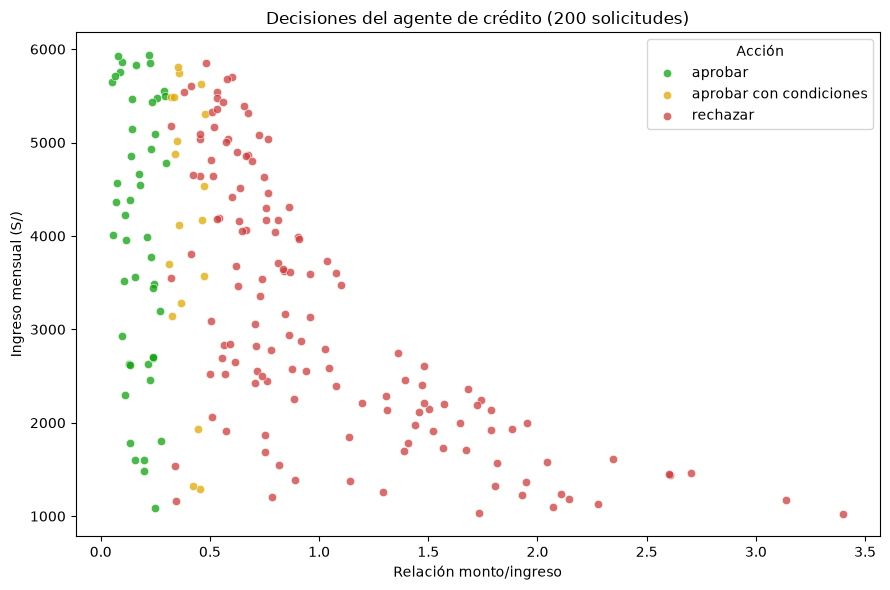

In [6]:
colores = {
    "aprobar": "#0ca30c",
    "aprobar con condiciones": "#e0a800",
    "rechazar": "#d03b3b",
}

fig, ax = plt.subplots(figsize=(9, 6))
for accion in colores:
    idx = [i for i in range(n) if acciones[i] == accion]
    ax.scatter(
        [relaciones[i] for i in idx],
        [ingresos[i] for i in idx],
        c=colores[accion], label=accion, alpha=0.75, edgecolors="white", linewidths=0.5,
    )

ax.set_xlabel("Relación monto/ingreso")
ax.set_ylabel("Ingreso mensual (S/)")
ax.set_title("Decisiones del agente de crédito (200 solicitudes)")
ax.legend(title="Acción")
plt.tight_layout()
plt.show()